<h2 style="text-align:center">Importar librereias</h2>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import os

<h4>Obtener Archivo .csv</h4>

In [3]:
file_path = os.path.join(os.getcwd(), "data" , "nutritional_food.csv")
csv_data = pd.read_csv(file_path)

<h2 style="text-align:center">Datos Generales (Todos los productos)</h2>


<hr style="color:blue">

Definir la Función de Moda Y Rango

In [4]:
mode_func = lambda x: x.mode().iloc[0]
mode_func.__name__ = "mode"  


Calcular Promedio / Mediana / Moda para Todos los Nutrientes

In [5]:
nutrient_cols = ["serving_size", "calories", "fat", "sodium", "sugars"]

summary_table = (
    csv_data.groupby("restaurant")[nutrient_cols]
    .agg(["mean", "median", mode_func])
)

summary_table

serving_size                calories                    fat  \
                        mean median mode        mean median mode       mean   
restaurant                                                                    
Burger King       218.000000  248.0   58  540.000000  610.0  170  29.909091   
Carl's Jr.        249.923077  250.0   93  585.307692  591.0  220  34.230769   
Chick-fil-A       184.600000  170.0   57  330.000000  280.0  130  12.200000   
Dairy Queen       217.545455  198.0  128  516.363636  550.0  380  27.090909   
Hardee's          291.166667  298.0  126  691.666667  700.0  260  39.666667   
In-N-Out Burger   257.400000  268.0  125  505.000000  480.0  390  26.800000   
Jack in the Box   200.615385  181.0   77  541.538462  490.0  240  29.384615   
McDonald's        180.636364  202.0   65  441.818182  510.0  530  20.363636   
Sonic             233.545455  257.0   80  588.181818  580.0  250  33.818182   
Wendy's           225.666667  239.0  247  549.166667  545.0  580  27.250000   
Whataburger       276.083333  300.5   85  603.333333  495.0  430  30.000000   
White Castle      132.900000  102.5   44  319.000000  315.0  140  18.800000   

                                  sodium                   sugars              
                median mode         mean  median  mode       mean median mode  
restaurant                                                                     
Burger King       18.0    8   817.272727   700.0   310  14.000000    7.0    0  
Carl's Jr.        31.0   11  1085.923077  1143.0   300  12.923077   10.0    0  
Chick-fil-A       14.0    3   654.000000   545.0   105  18.400000    5.0    0  
Dairy Queen       28.0   19  1001.818182  1040.0   220  12.090909    8.0    0  
Hardee's          36.5   13  1399.166667  1500.0   240  14.916667   11.0    0  
In-N-Out Burger   27.0   18   731.000000   650.0   245  19.000000   10.0   10  
Jack in the Box   23.0   11  1082.307692   910.0   880  11.692308    6.0    6  
McDonald's        15.0   11   766.363636   820.0   130  12.454545    9.0   10  
Sonic             29.0   17   926.363636   900.0  1260  10.000000    7.0    7  
Wendy's           17.5   13  1057.500000  1040.0   250  14.166667    9.0    9  
Whataburger       21.0    9  1149.166667  1095.0  1050  14.750000   12.0    6  
White Castle      15.5    6   568.000000   535.0    50  10.600000    2.0    2

#### Cambiando nombres de columnas

In [6]:
nombre_stat = {
    "mean": "promedio",
    "median": "mediana",
    "mode": "moda"
}

summary_table.columns = [
    f"{nombre_stat[stat]}_{col}" for col, stat in summary_table.columns
]

summary_table = summary_table.reset_index()
print(summary_table.columns)

Index(['restaurant', 'promedio_serving_size', 'mediana_serving_size',
       'moda_serving_size', 'promedio_calories', 'mediana_calories',
       'moda_calories', 'promedio_fat', 'mediana_fat', 'moda_fat',
       'promedio_sodium', 'mediana_sodium', 'moda_sodium', 'promedio_sugars',
       'mediana_sugars', 'moda_sugars'],
      dtype='str')


#### Medidas de Dispersión 

In [7]:
range_func = lambda x: x.max() - x.min()
range_func.__name__ = "range"

In [8]:
nutrient_cols = ["serving_size", "calories", "fat", "sodium", "sugars"]

summary_table_dis = (
    csv_data.groupby("restaurant")[nutrient_cols]
    .agg(["std", "var", range_func])
)

summary_table_dis


serving_size                        calories                \
                         std           var range         std           var   
restaurant                                                                   
Burger King       105.518719  11134.200000   285  281.531526  79260.000000   
Carl's Jr.        113.379497  12854.910256   323  266.684703  71120.730769   
Chick-fil-A       142.268408  20240.300000   361  162.326831  26350.000000   
Dairy Queen        72.896315   5313.872727   245  134.258909  18025.454545   
Hardee's          113.447492  12870.333333   341  259.819285  67506.060606   
In-N-Out Burger    82.409344   6791.300000   205  122.882057  15100.000000   
Jack in the Box    99.381033   9876.589744   299  247.280076  61147.435897   
McDonald's         79.391779   6303.054545   218  194.721246  37916.363636   
Sonic             110.201056  12144.272727   316  280.493072  78676.363636   
Wendy's           112.164922  12580.969697   363  289.025269  83535.606061   
Whataburger        97.886259   9581.719697   315  289.115684  83587.878788   
White Castle      116.543220  13582.322222   406  147.229979  21676.666667   

                             fat                        sodium                 \
                range        std         var range         std            var   
restaurant                                                                      
Burger King       870  20.944949  438.690909    61  477.097284  227621.818182   
Carl's Jr.        800  20.273767  411.025641    59  448.472307  201127.410256   
Chick-fil-A       430   7.694154   59.200000    19  471.028131  221867.500000   
Dairy Queen       420   9.669070   93.490909    30  320.743455  102876.363636   
Hardee's          880  20.575066  423.333333    66  629.002939  395644.696970   
In-N-Out Burger   280   9.284396   86.200000    23  496.668904  246680.000000   
Jack in the Box   790  17.830398  317.923077    60  557.332245  310619.230769   
McDonald's        560  12.379602  153.254545    35  445.853625  198785.454545   
Sonic             990  21.586191  465.963636    75  442.973424  196225.454545   
Wendy's           910  19.945950  397.840909    59  616.310503  379838.636364   
Whataburger       830  21.178892  448.545455    60  549.337756  301771.969697   
White Castle      410  12.890996  166.177778    41  325.740183  106106.666667   

                          sugars                     
                range        std          var range  
restaurant                                           
Burger King      1590  24.827404   616.400000    88  
Carl's Jr.       1460  15.478273   239.576923    59  
Chick-fil-A      1195  33.997059  1155.800000    79  
Dairy Queen      1190  19.861795   394.490909    71  
Hardee's         2220  19.114289   365.356061    73  
In-N-Out Burger  1195  26.076810   680.000000    65  
Jack in the Box  1890  23.084571   532.897436    88  
McDonald's       1340  17.287936   298.872727    63  
Sonic            1430  15.588457   243.000000    56  
Wendy's          1740  25.099197   629.969697    93  
Whataburger      1910  20.334141   413.477273    77  
White Castle     1170  27.909377   778.933333    90

#### Calorías por Restaurante

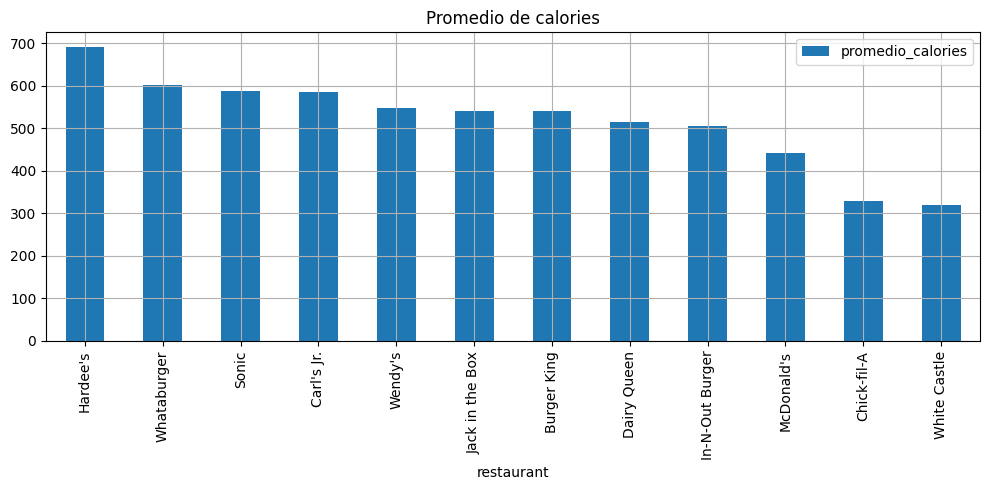

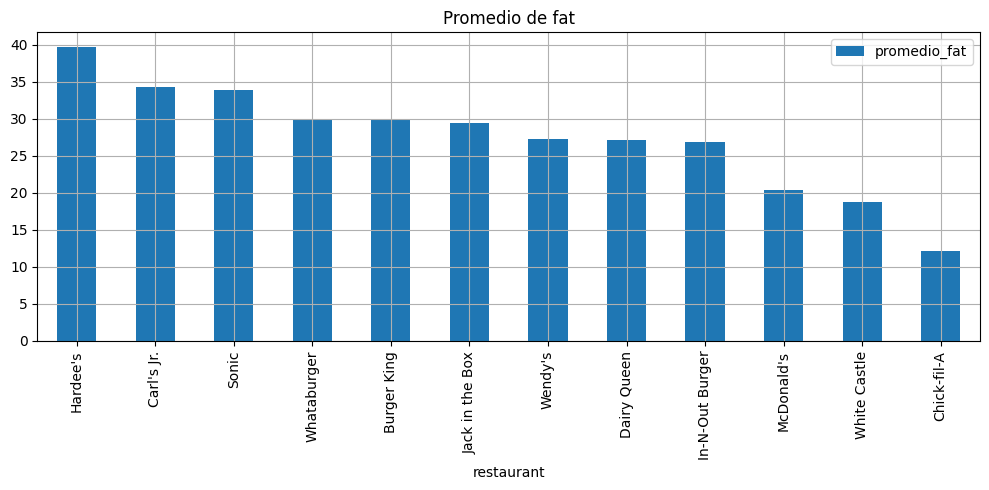

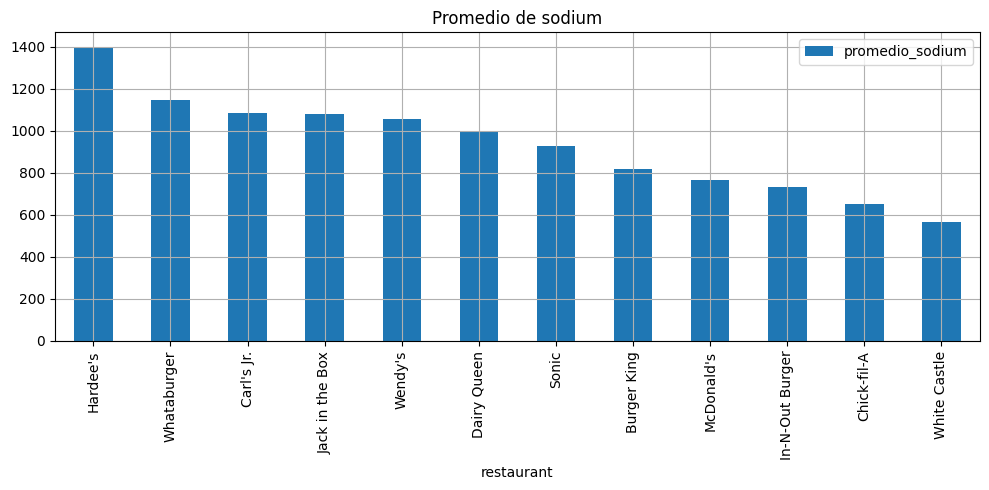

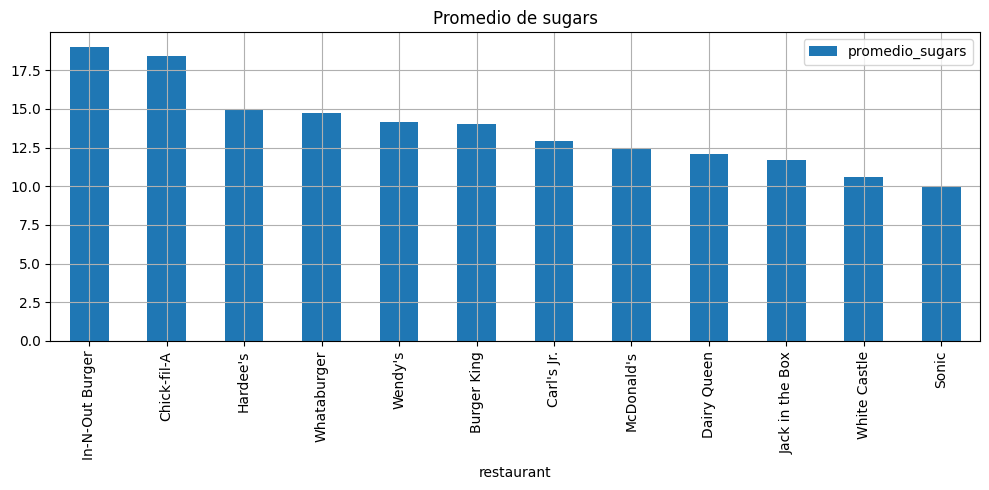

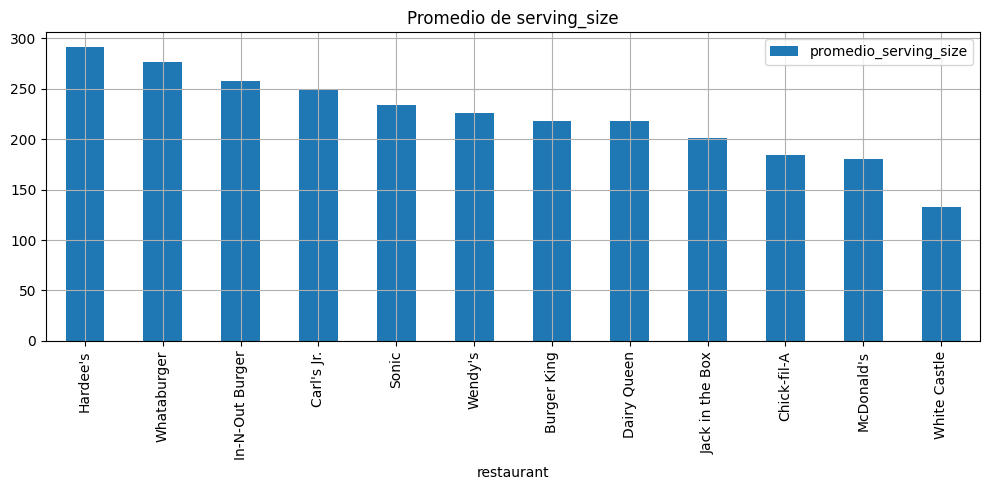

In [9]:
for nutriente in ["calories", "fat", "sodium", "sugars", "serving_size"]:
    col = f"promedio_{nutriente}"
    summary_table.sort_values(col, ascending=False).plot(
        x="restaurant", y=col, kind="bar", figsize=(10,5), title=f"Promedio de {nutriente}" , grid=True
    )
    plt.tight_layout()
    plt.show()

In [10]:
white_castle = summary_table.iloc[-1]
white_castle

restaurant               White Castle
promedio_serving_size           132.9
mediana_serving_size            102.5
moda_serving_size                  44
promedio_calories               319.0
mediana_calories                315.0
moda_calories                     140
promedio_fat                     18.8
mediana_fat                      15.5
moda_fat                            6
promedio_sodium                 568.0
mediana_sodium                  535.0
moda_sodium                        50
promedio_sugars                  10.6
mediana_sugars                    2.0
moda_sugars                         2
Name: 11, dtype: object

In [11]:
white_castle_div = summary_table_dis.iloc[-1]
white_castle_div

serving_size  std         116.543220
              var       13582.322222
              range       406.000000
calories      std         147.229979
              var       21676.666667
              range       410.000000
fat           std          12.890996
              var         166.177778
              range        41.000000
sodium        std         325.740183
              var      106106.666667
              range      1170.000000
sugars        std          27.909377
              var         778.933333
              range        90.000000
Name: White Castle, dtype: float64

<h2 style="text-align:center">Product Stats</h2>


<hr style="color:blue">

In [12]:
nombre_stat_central = {"mean": "promedio", "median": "mediana", "mode": "moda"}
nombre_stat_dis = {"std": "desviacion_estandar", "var": "varianza", "range": "rango"}

mode_func.__name__ = "mode"
range_func.__name__ = "range"

In [13]:
summary_table_restaurant_item = (
    csv_data.groupby(["restaurant", "item"])[nutrient_cols]
    .agg(["mean", "median", mode_func])
)
summary_table_restaurant_item.columns = [
    f"{nombre_stat_central[stat]}_{col}"
    for col, stat in summary_table_restaurant_item.columns
]
summary_table_restaurant_item = summary_table_restaurant_item.reset_index()

summary_table_restaurant_item

,restaurant,item,promedio_serving_size,mediana_serving_size,moda_serving_size,promedio_calories,mediana_calories,moda_calories,promedio_fat,mediana_fat,moda_fat,promedio_sodium,mediana_sodium,moda_sodium,promedio_sugars,mediana_sugars,moda_sugars
0,Burger King,Bacon & Cheese Whopper Sandwich,279.0,279.0,279,750.0,750.0,750,49.0,49.0,49,1260.0,1260.0,1260,8.0,8.0,8
1,Burger King,Cheeseburger,104.0,104.0,104,270.0,270.0,270,12.0,12.0,12,560.0,560.0,560,7.0,7.0,7
2,Burger King,Chicken Nuggets (4pc),58.0,58.0,58,170.0,170.0,170,11.0,11.0,11,310.0,310.0,310,0.0,0.0,0
3,Burger King,Chocolate Milk Shake,343.0,343.0,343,610.0,610.0,610,16.0,16.0,16,500.0,500.0,500,88.0,88.0,88
4,Burger King,Double Bacon King,327.0,327.0,327,1040.0,1040.0,1040,69.0,69.0,69,1900.0,1900.0,1900,10.0,10.0,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,White Castle,Double Bacon Ch Slider,121.0,121.0,121,400.0,400.0,400,27.0,27.0,27,1220.0,1220.0,1220,2.0,2.0,2
121,White Castle,Double Cheese Slider,113.0,113.0,113,300.0,300.0,300,17.0,17.0,17,940.0,940.0,940,3.0,3.0,3
122,White Castle,French Fries (Small),148.0,148.0,148,330.0,330.0,330,21.0,21.0,21,50.0,50.0,50,2.0,2.0,2
123,White Castle,Savory Grilled Chicken Slider,88.0,88.0,88,180.0,180.0,180,7.0,7.0,7,570.0,570.0,570,2.0,2.0,2


In [14]:
types_comunes = csv_data.groupby("type")["restaurant"].nunique()
types_comunes = types_comunes[types_comunes > 1].index

csv_data_comunes = csv_data[csv_data["type"].isin(types_comunes)]
print(types_comunes.tolist())

['Breaded Chicken Sandwich', 'Burger', 'Chicken Nuggets', 'French Fries', 'Grilled Chicken Sandwich', 'Milkshake']


In [15]:
summary_table_type_restaurant = (
    csv_data_comunes.groupby(["type", "restaurant"])[nutrient_cols]
    .agg(["mean", "median", mode_func])
)
summary_table_type_restaurant.columns = [
    f"{nombre_stat_central[stat]}_{col}"
    for col, stat in summary_table_type_restaurant.columns
]
summary_table_type_restaurant = summary_table_type_restaurant.reset_index()

summary_table_type_restaurant

,type,restaurant,promedio_serving_size,mediana_serving_size,moda_serving_size,promedio_calories,mediana_calories,moda_calories,promedio_fat,mediana_fat,moda_fat,promedio_sodium,mediana_sodium,moda_sodium,promedio_sugars,mediana_sugars,moda_sugars
0,Breaded Chicken Sandwich,Burger King,248.0,248.0,248,660.0,660.0,660,40.0,40.0,40,1220.0,1220.0,1220,7.0,7.0,7
1,Breaded Chicken Sandwich,Carl's Jr.,207.0,207.0,207,493.0,493.0,493,23.0,23.0,23,1287.0,1287.0,1287,0.0,0.0,0
2,Breaded Chicken Sandwich,Chick-fil-A,170.0,170.0,170,410.0,410.0,410,16.0,16.0,16,1300.0,1300.0,1300,5.0,5.0,5
3,Breaded Chicken Sandwich,Dairy Queen,198.0,198.0,198,610.0,610.0,610,30.0,30.0,30,1120.0,1120.0,1120,5.0,5.0,5
4,Breaded Chicken Sandwich,Hardee's,329.0,329.0,329,750.0,750.0,750,42.0,42.0,42,1490.0,1490.0,1490,11.0,11.0,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,Milkshake,McDonald's,257.0,257.0,257,530.0,530.0,530,15.0,15.0,15,160.0,160.0,160,63.0,63.0,63
64,Milkshake,Sonic,387.0,387.0,387,670.0,670.0,670,31.0,31.0,31,330.0,330.0,330,56.0,56.0,56
65,Milkshake,Wendy's,342.0,342.0,342,580.0,580.0,580,13.0,13.0,13,250.0,250.0,250,93.0,93.0,93
66,Milkshake,Whataburger,343.0,343.0,343,430.0,430.0,430,9.0,9.0,9,400.0,400.0,400,77.0,77.0,77


In [16]:
summary_table_dis_type = (
    csv_data_comunes.groupby("type")[nutrient_cols]
    .agg(["std", "var", range_func])
)

summary_table_dis_type = summary_table_dis_type.reset_index()

summary_table_dis_type

type serving_size                        calories  \
                                     std           var range         std   
0  Breaded Chicken Sandwich    64.844569   4204.818182   237  117.038844   
1                    Burger   104.576116  10936.164109   423  277.160581   
2           Chicken Nuggets    41.850600   1751.472727   126  119.780102   
3              French Fries    24.648437    607.545455    73   49.690786   
4  Grilled Chicken Sandwich    52.477528   2753.890909   197  124.016128   
5                 Milkshake    50.271988   2527.272727   193   98.841777   

                             fat                        sodium                 \
            var range        std         var range         std            var   
0  13698.090909   370   9.208692   84.800000    29  275.942847   76144.454545   
1  76817.987639  1100  20.351138  414.168798    81  490.755048  240840.517050   
2  14347.272727   400  10.956941  120.054545    41  310.828658   96614.454545   
3   2469.174242   165   2.800162    7.840909    10  258.041869   66585.606061   
4  15380.000000   410   9.797959   96.000000    28  302.481855   91495.272727   
5   9769.696970   370  10.387565  107.901515    29   90.096749    8117.424242   

            sugars                    
  range        std         var range  
0  1030   3.882361   15.072727    13  
1  2100   4.073389   16.592498    19  
2   950   0.467099    0.218182     1  
3   740   0.577350    0.333333     2  
4   940   2.935674    8.618182    12  
5   340  12.748143  162.515152    37

In [17]:
summary_table_item = (
    csv_data_comunes.groupby("item")[nutrient_cols]
    .agg(["mean", "median", mode_func])
)

summary_table_item.columns = [
    f"{nombre_stat_central[stat]}_{col}" for col, stat in summary_table_item.columns
]
summary_table_item = summary_table_item.reset_index()

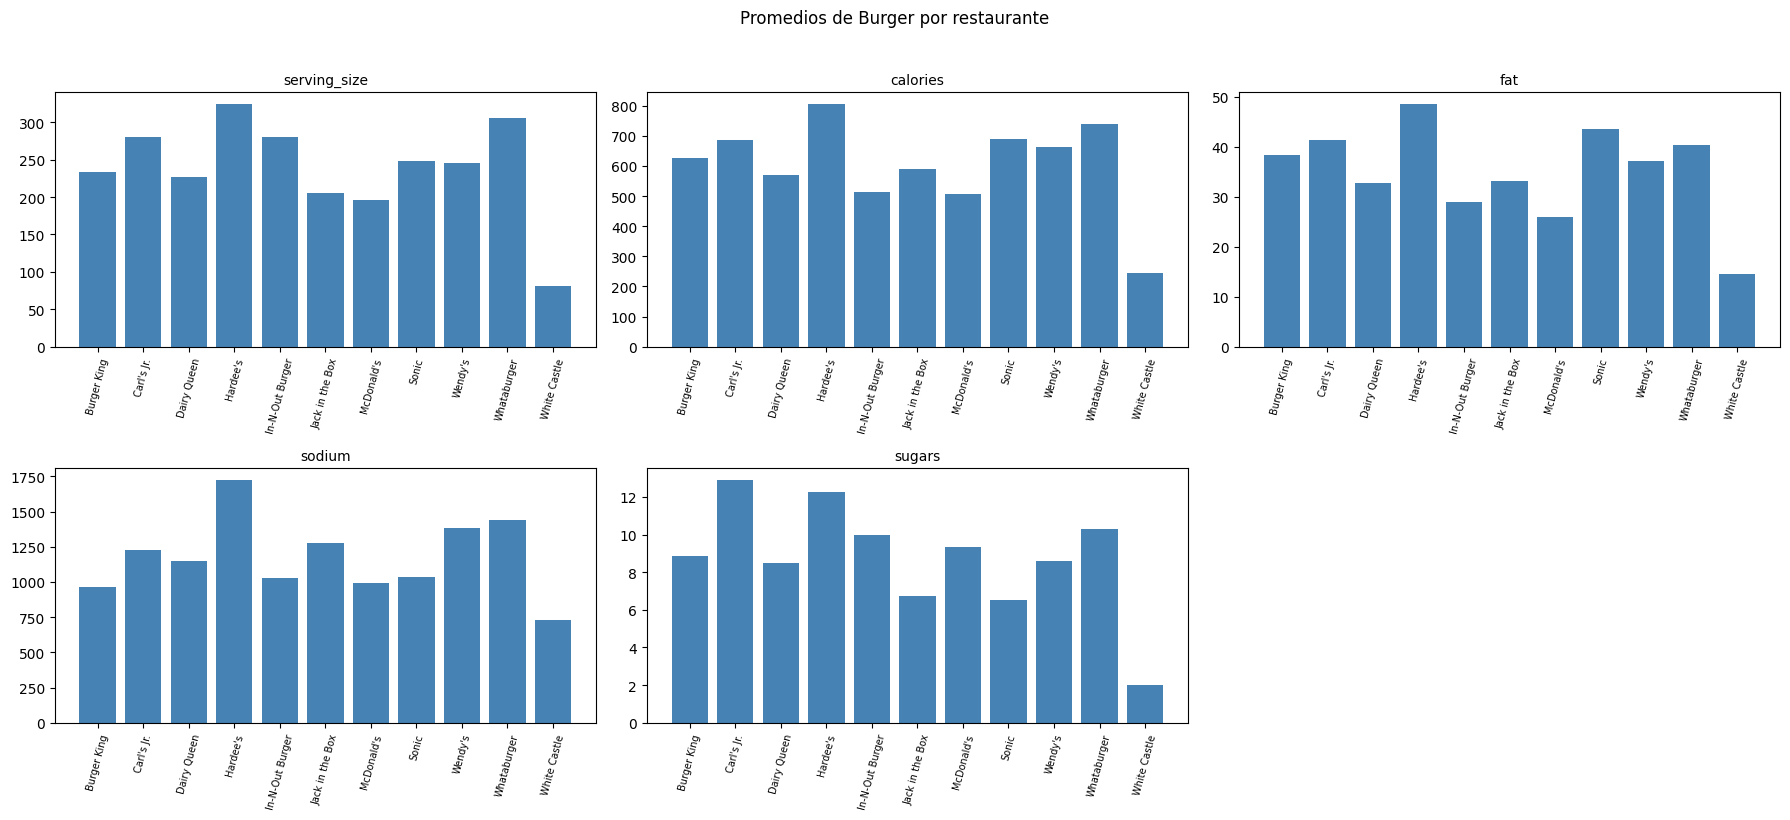

In [18]:
tipo = "Burger"
datos_tipo = summary_table_type_restaurant[summary_table_type_restaurant["type"] == tipo]

cols = 3
rows = -(-len(nutrient_cols) // cols)

fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
axes = axes.flatten()

for ax, nutriente in zip(axes, nutrient_cols):
    ax.bar(datos_tipo["restaurant"], datos_tipo[f"promedio_{nutriente}"], color="steelblue")
    ax.set_title(nutriente, fontsize=10)
    ax.tick_params(axis='x', rotation=75, labelsize=7)

for ax in axes[len(nutrient_cols):]:
    ax.axis("off")

plt.suptitle(f"Promedios de {tipo} por restaurante", y=1.02)
plt.tight_layout()
plt.show()

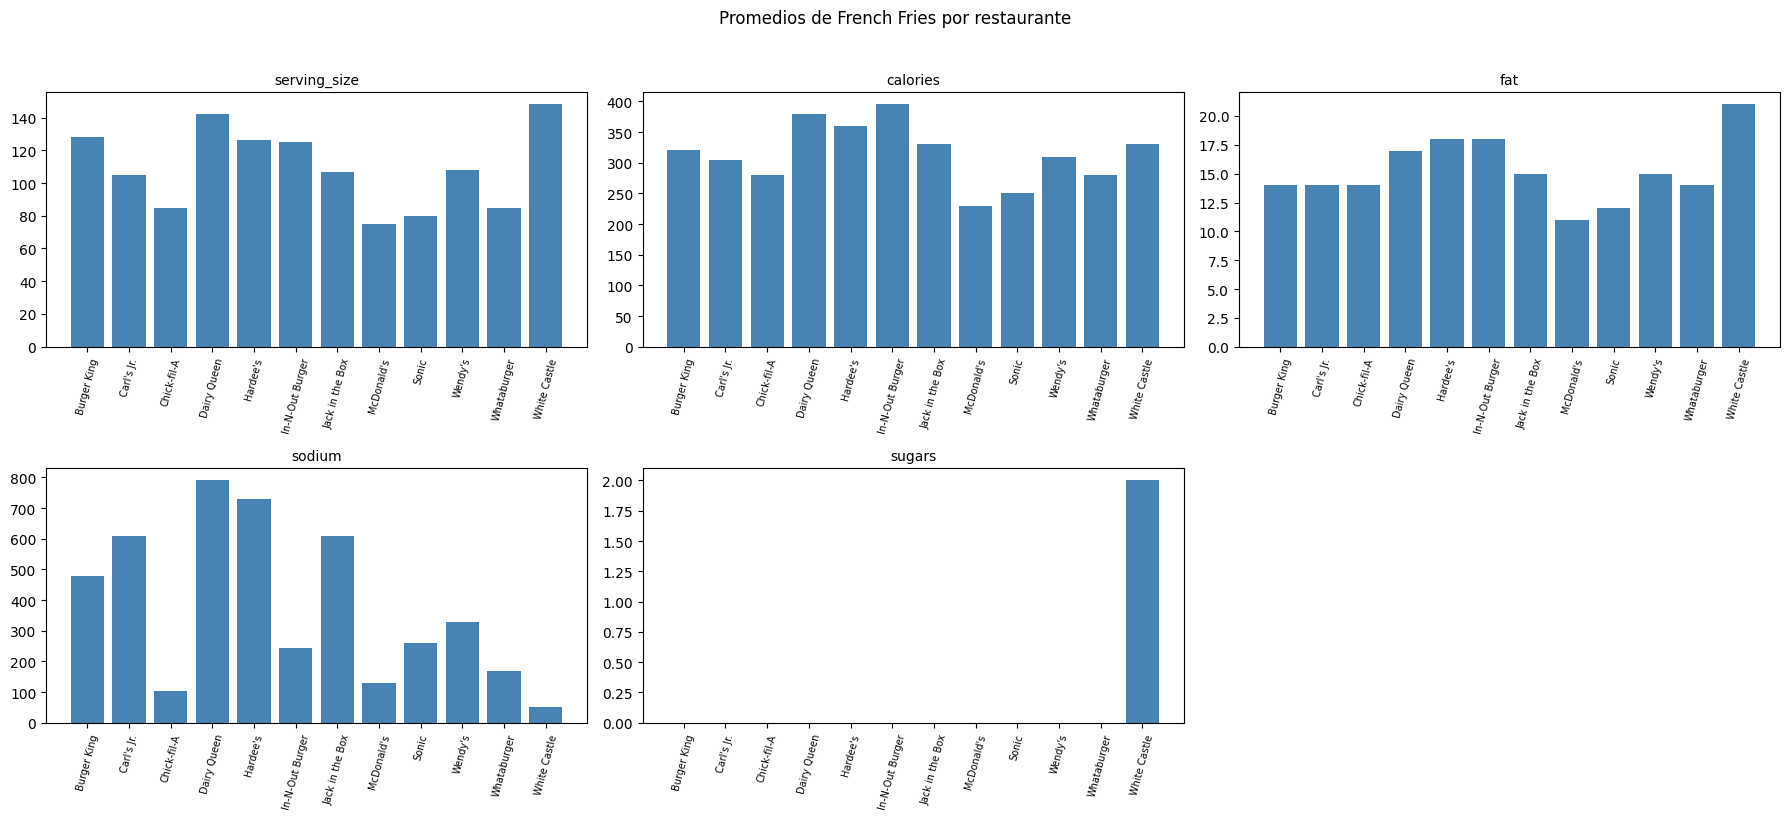

In [24]:
tipo = "French Fries"
datos_tipo = summary_table_type_restaurant[summary_table_type_restaurant["type"] == tipo]

cols = 3
rows = -(-len(nutrient_cols) // cols)

fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
axes = axes.flatten()

for ax, nutriente in zip(axes, nutrient_cols):
    ax.bar(datos_tipo["restaurant"], datos_tipo[f"promedio_{nutriente}"], color="steelblue")
    ax.set_title(nutriente, fontsize=10)
    ax.tick_params(axis='x', rotation=75, labelsize=7)

for ax in axes[len(nutrient_cols):]:
    ax.axis("off")

plt.suptitle(f"Promedios de {tipo} por restaurante", y=1.02)
plt.tight_layout()
plt.show()

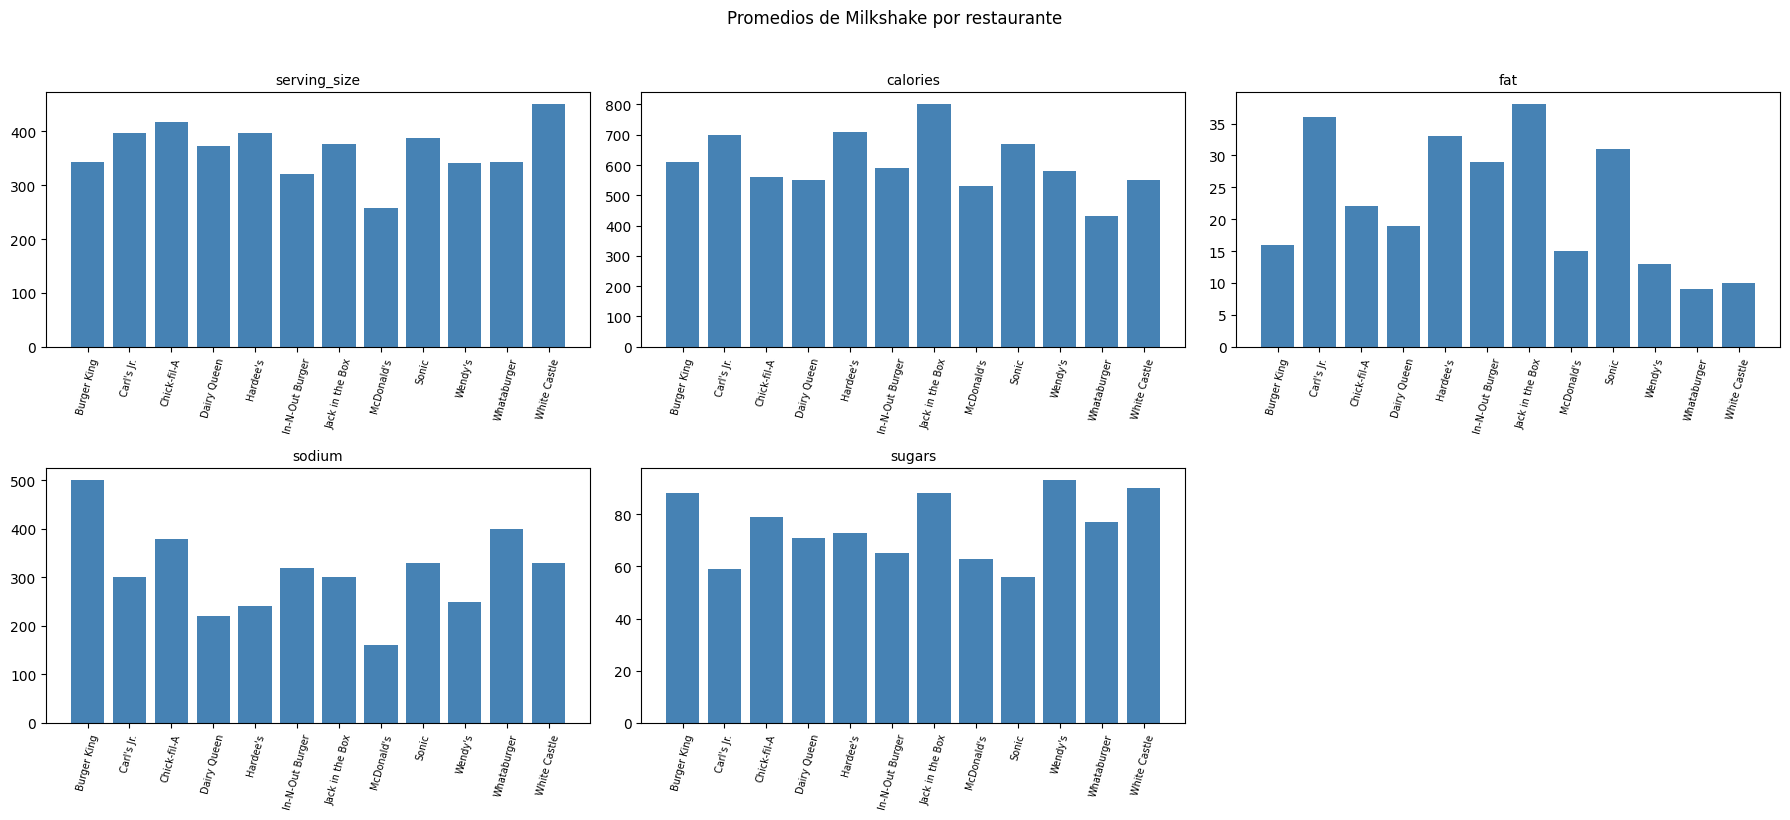

In [21]:
tipo = "Milkshake"
datos_tipo = summary_table_type_restaurant[summary_table_type_restaurant["type"] == tipo]

cols = 3
rows = -(-len(nutrient_cols) // cols)

fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
axes = axes.flatten()

for ax, nutriente in zip(axes, nutrient_cols):
    ax.bar(datos_tipo["restaurant"], datos_tipo[f"promedio_{nutriente}"], color="steelblue")
    ax.set_title(nutriente, fontsize=10)
    ax.tick_params(axis='x', rotation=75, labelsize=7)

for ax in axes[len(nutrient_cols):]:
    ax.axis("off")

plt.suptitle(f"Promedios de {tipo} por restaurante", y=1.02)
plt.tight_layout()
plt.show()

#### Calcular densidad por unidad de tamaño (Cuanto nutriente hay por cada porción)

In [22]:
nutrientes = ["calories", "fat", "sodium", "sugars"]

densidad = csv_data.copy()
for col in nutrientes:
    densidad[f"{col}_por_gramo"] = densidad[col] / densidad["serving_size"]

densidad_restaurante = (
    densidad.groupby("restaurant")[[f"{col}_por_gramo" for col in nutrientes]]
    .mean()
    .sort_values("calories_por_gramo", ascending=False)
)

densidad_restaurante

,calories_por_gramo,fat_por_gramo,sodium_por_gramo,sugars_por_gramo
restaurant,,,,
White Castle,2.829987,0.176018,6.088597,0.038538
Jack in the Box,2.787188,0.146900,5.923666,0.044445
Sonic,2.644035,0.148101,4.523076,0.033480
McDonald's,2.510424,0.115789,4.320057,0.057691
Burger King,2.504757,0.134770,4.014689,0.052553
Wendy's,2.502445,0.124236,4.983717,0.051287
Dairy Queen,2.457047,0.129325,5.044809,0.043325
Hardee's,2.407327,0.132696,5.080838,0.043159
Carl's Jr.,2.381284,0.132604,4.928267,0.042180


### No te dejes engañar por el tamaño.